# Baselines — Telco Customer Churn

**Objetivo:** treinar modelos baseline, estabelecer floor de performance e registrar experimentos no MLflow.

Modelos: DummyClassifier · LogisticRegression · RandomForest · GradientBoosting · XGBoost

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
import mlflow
import mlflow.sklearn

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from xgboost import XGBClassifier

from src import SEED
from src.data.loader import load_splits
from src.data.preprocessing import build_preprocessor, prepare_xy
from src.evaluation.metrics import compute_metrics, optimal_threshold

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(f'SEED={SEED} | MLflow version: {mlflow.__version__}')

SEED=42 | MLflow version: 3.14.0


## 1. Carregar Dados e Pré-processar

In [2]:
train_df, val_df, test_df = load_splits(base_dir='../data/raw')

preprocessor = build_preprocessor()

X_train, y_train = prepare_xy(train_df)
X_val,   y_val   = prepare_xy(val_df)
X_test,  y_test  = prepare_xy(test_df)

X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f'Train: {X_train_proc.shape} | Val: {X_val_proc.shape} | Test: {X_test_proc.shape}')
print(f'Features após encoding: {X_train_proc.shape[1]}')

Train: (5633, 45) | Val: (705, 45) | Test: (705, 45)
Features após encoding: 45


In [3]:
# Salvar preprocessor para uso na API
import os
os.makedirs('../models', exist_ok=True)
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print('preprocessor.pkl salvo em ../models/')

preprocessor.pkl salvo em ../models/


## 2. Configuração — MLflow + Cross-Validation

In [4]:
mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('churn-baselines')

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ['roc_auc', 'average_precision', 'f1']

BASELINES = {
    'dummy': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=SEED, C=1.0),
    'random_forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'xgboost': XGBClassifier(
        n_estimators=100, random_state=SEED,
        eval_metric='logloss', verbosity=0, n_jobs=-1
    ),
}

print('Modelos configurados:', list(BASELINES.keys()))

2026/06/17 15:06:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/17 15:06:44 INFO mlflow.store.db.utils: Updating database tables


2026/06/17 15:06:44 INFO mlflow.tracking.fluent: Experiment with name 'churn-baselines' does not exist. Creating a new experiment.


Modelos configurados: ['dummy', 'logistic_regression', 'random_forest', 'gradient_boosting', 'xgboost']


## 3. Treino com Cross-Validation + MLflow Tracking

In [5]:
results_cv = {}
results_test = {}
trained_models = {}

for name, model in BASELINES.items():
    print(f'\nTraining: {name}...')

    # Cross-validation no train set
    scores = cross_validate(
        model, X_train_proc, y_train,
        cv=CV, scoring=SCORING, return_train_score=True,
    )

    cv_metrics = {
        'cv_roc_auc_mean': float(np.mean(scores['test_roc_auc'])),
        'cv_roc_auc_std':  float(np.std(scores['test_roc_auc'])),
        'cv_pr_auc_mean':  float(np.mean(scores['test_average_precision'])),
        'cv_f1_mean':      float(np.mean(scores['test_f1'])),
        'cv_fit_time_mean':float(np.mean(scores['fit_time'])),
    }

    # Treinar no train completo
    model.fit(X_train_proc, y_train)
    trained_models[name] = model

    # Avaliar no test set
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_proc)[:, 1]
    else:
        y_prob = model.predict(X_test_proc).astype(float)

    threshold = optimal_threshold(y_test, y_prob) if name != 'dummy' else 0.5
    test_metrics = compute_metrics(y_test, y_prob, threshold=threshold)

    results_cv[name] = cv_metrics
    results_test[name] = test_metrics

    # MLflow log
    with mlflow.start_run(run_name=name):
        mlflow.log_params({'model': name, 'cv_folds': 5, 'seed': SEED})
        mlflow.log_metrics({**cv_metrics, **{
            'test_roc_auc':  test_metrics['roc_auc'],
            'test_pr_auc':   test_metrics['pr_auc'],
            'test_f1':       test_metrics['f1'],
            'test_business_cost': test_metrics['business_cost'],
            'test_threshold': threshold,
        }})
        mlflow.sklearn.log_model(model, name='model', serialization_format='cloudpickle')

    print(f'  CV AUC-ROC: {cv_metrics["cv_roc_auc_mean"]:.4f} ± {cv_metrics["cv_roc_auc_std"]:.4f}')
    print(f'  Test AUC-ROC: {test_metrics["roc_auc"]:.4f} | F1: {test_metrics["f1"]:.4f} | Custo: R${test_metrics["business_cost"]:,.0f}')

print('\n✅ Todos os baselines treinados e logados no MLflow')

2026/06/17 15:06:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: dummy...


2026/06/17 15:06:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV AUC-ROC: 0.5000 ± 0.0000
  Test AUC-ROC: 0.5000 | F1: 0.0000 | Custo: R$93,500

Training: logistic_regression...


  CV AUC-ROC: 0.8434 ± 0.0117
  Test AUC-ROC: 0.8528 | F1: 0.5710 | Custo: R$18,550

Training: random_forest...


...

  CV AUC-ROC: 0.8190 ± 0.0106
  Test AUC-ROC: 0.8211 | F1: 0.5629 | Custo: R$20,850

Training: gradient_boosting...


2026/06/17 15:06:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV AUC-ROC: 0.8464 ± 0.0094
  Test AUC-ROC: 0.8510 | F1: 0.5876 | Custo: R$19,200

Training: xgboost...


2026/06/17 15:06:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  CV AUC-ROC: 0.8199 ± 0.0092
  Test AUC-ROC: 0.8294 | F1: 0.5891 | Custo: R$22,550

✅ Todos os baselines treinados e logados no MLflow


## 4. Tabela Comparativa

In [6]:
rows = []
for name in BASELINES:
    cv = results_cv[name]
    te = results_test[name]
    rows.append({
        'Modelo': name,
        'CV AUC-ROC': f"{cv['cv_roc_auc_mean']:.4f} ± {cv['cv_roc_auc_std']:.4f}",
        'CV PR-AUC': f"{cv['cv_pr_auc_mean']:.4f}",
        'CV F1': f"{cv['cv_f1_mean']:.4f}",
        'Test AUC-ROC': f"{te['roc_auc']:.4f}",
        'Test PR-AUC': f"{te['pr_auc']:.4f}",
        'Test F1': f"{te['f1']:.4f}",
        'Custo Negócio': f"R${te['business_cost']:,.0f}",
        'Threshold': f"{te['threshold']:.2f}",
    })

df_results = pd.DataFrame(rows).set_index('Modelo')
print('=== TABELA COMPARATIVA — BASELINES ===')
df_results

=== TABELA COMPARATIVA — BASELINES ===


,CV AUC-ROC,CV PR-AUC,CV F1,Test AUC-ROC,Test PR-AUC,Test F1,Custo Negócio,Threshold
Modelo,,,,,,,,
dummy,0.5000 ± 0.0000,0.2654,0.0000,0.5000,0.2652,0.0000,"R$93,500",0.50
logistic_regression,0.8434 ± 0.0117,0.6555,0.5969,0.8528,0.6575,0.5710,"R$18,550",0.10
random_forest,0.8190 ± 0.0106,0.6120,0.5372,0.8211,0.6273,0.5629,"R$20,850",0.11
gradient_boosting,0.8464 ± 0.0094,0.6621,0.5854,0.8510,0.6775,0.5876,"R$19,200",0.12
xgboost,0.8199 ± 0.0092,0.6143,0.5498,0.8294,0.6510,0.5891,"R$22,550",0.10


## 5. Visualização — Comparação de Métricas

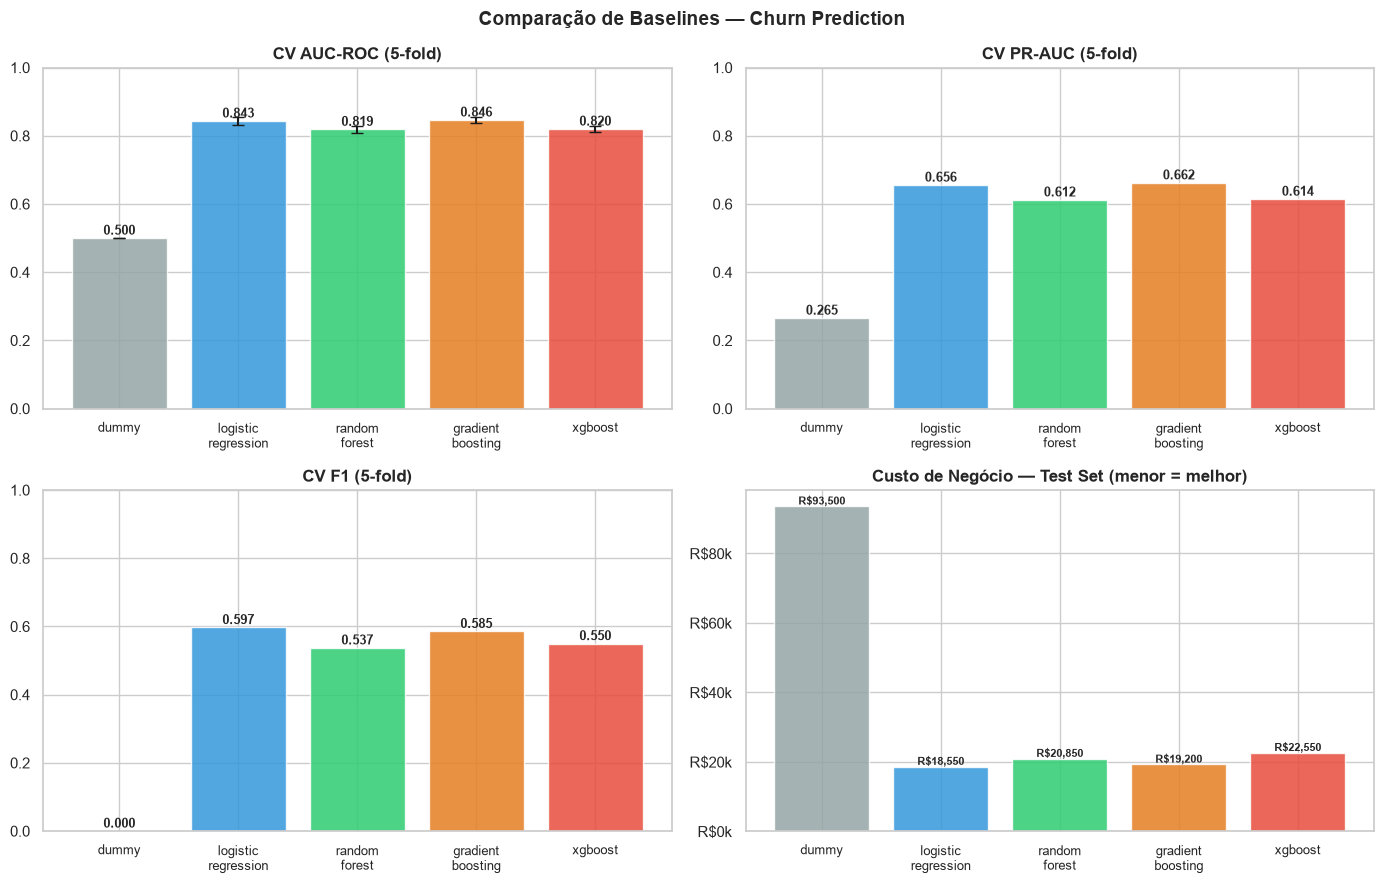

In [7]:
models_names = list(BASELINES.keys())
auc_means = [results_cv[n]['cv_roc_auc_mean'] for n in models_names]
auc_stds  = [results_cv[n]['cv_roc_auc_std']  for n in models_names]
pr_aucs   = [results_cv[n]['cv_pr_auc_mean']  for n in models_names]
f1s       = [results_cv[n]['cv_f1_mean']       for n in models_names]
costs     = [results_test[n]['business_cost']  for n in models_names]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

colors = ['#95a5a6', '#3498db', '#2ecc71', '#e67e22', '#e74c3c']
x = np.arange(len(models_names))
labels = [n.replace('_', '\n') for n in models_names]

# AUC-ROC
bars = axes[0,0].bar(x, auc_means, yerr=auc_stds, capsize=4, color=colors, alpha=0.85)
axes[0,0].set_title('CV AUC-ROC (5-fold)', fontweight='bold')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(labels, fontsize=9)
axes[0,0].set_ylim(0, 1)
for bar, val in zip(bars, auc_means):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
                   ha='center', fontsize=9, fontweight='bold')

# PR-AUC
bars = axes[0,1].bar(x, pr_aucs, color=colors, alpha=0.85)
axes[0,1].set_title('CV PR-AUC (5-fold)', fontweight='bold')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(labels, fontsize=9)
axes[0,1].set_ylim(0, 1)
for bar, val in zip(bars, pr_aucs):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
                   ha='center', fontsize=9, fontweight='bold')

# F1
bars = axes[1,0].bar(x, f1s, color=colors, alpha=0.85)
axes[1,0].set_title('CV F1 (5-fold)', fontweight='bold')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels, fontsize=9)
axes[1,0].set_ylim(0, 1)
for bar, val in zip(bars, f1s):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
                   ha='center', fontsize=9, fontweight='bold')

# Custo Negócio (menor é melhor)
bars = axes[1,1].bar(x, costs, color=colors, alpha=0.85)
axes[1,1].set_title('Custo de Negócio — Test Set (menor = melhor)', fontweight='bold')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(labels, fontsize=9)
axes[1,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'R${v/1000:.0f}k'))
for bar, val in zip(bars, costs):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'R${val:,.0f}',
                   ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Comparação de Baselines — Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/baselines_comparison.png', bbox_inches='tight')
plt.show()

## 6. Curvas ROC — Test Set

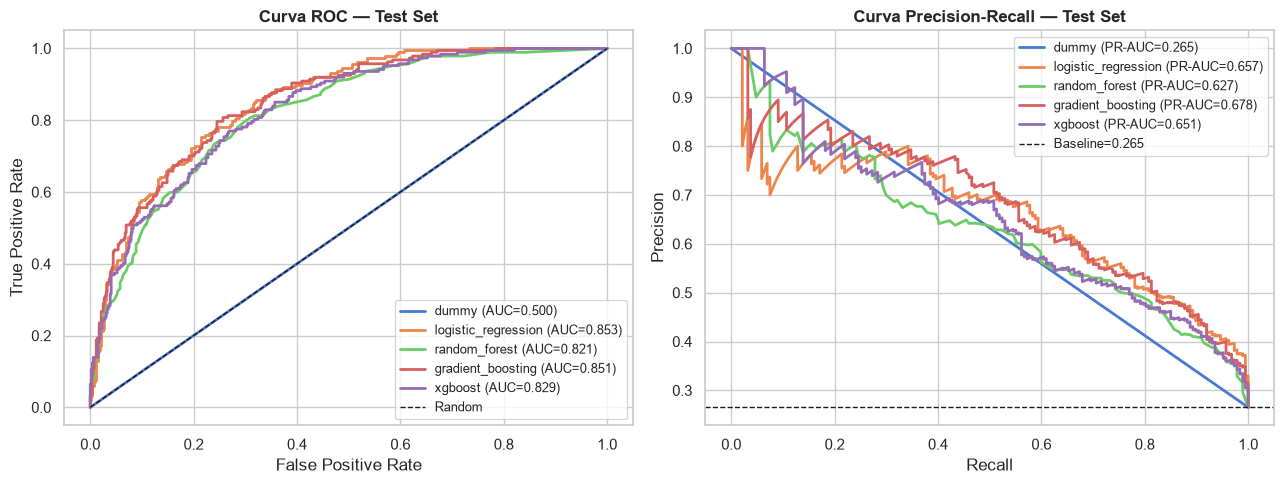

In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in trained_models.items():
    if not hasattr(model, 'predict_proba'):
        continue
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})', linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC — Test Set', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1, label=f'Baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Test Set', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../docs/baselines_roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 7. Análise de Custo × Threshold (melhor baseline)

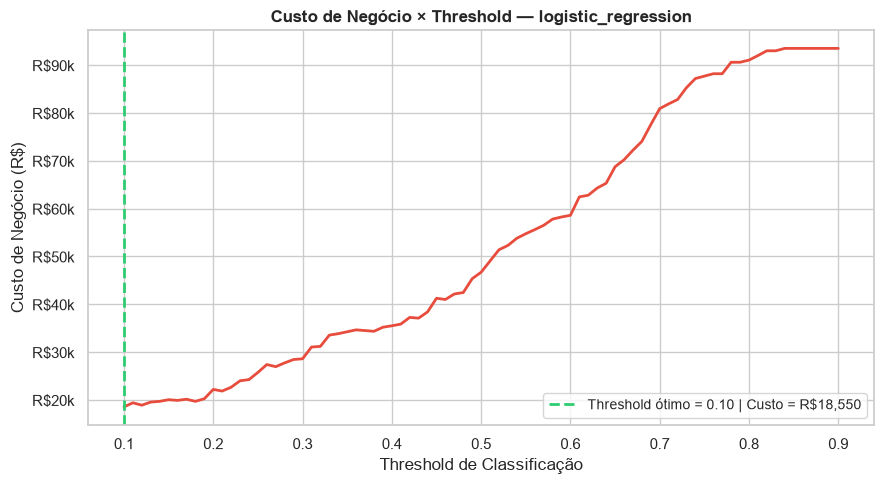

Melhor baseline: logistic_regression
Threshold ótimo: 0.10
Custo mínimo:    R$18,550


In [9]:
from src.evaluation.metrics import business_cost

# Usar o melhor baseline (excluindo dummy) por AUC-ROC
best_name = max(
    [n for n in BASELINES if n != 'dummy'],
    key=lambda n: results_test[n]['roc_auc']
)
best_model = trained_models[best_name]
y_prob_best = best_model.predict_proba(X_test_proc)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
costs = [business_cost(y_test, (y_prob_best >= t).astype(int)) for t in thresholds]
opt_threshold = thresholds[np.argmin(costs)]
opt_cost = min(costs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs, color='#e74c3c', linewidth=2)
ax.axvline(opt_threshold, color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Threshold ótimo = {opt_threshold:.2f} | Custo = R${opt_cost:,.0f}')
ax.set_xlabel('Threshold de Classificação')
ax.set_ylabel('Custo de Negócio (R$)')
ax.set_title(f'Custo de Negócio × Threshold — {best_name}', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'R${v/1000:.0f}k'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../docs/baselines_cost_threshold.png', bbox_inches='tight')
plt.show()

print(f'Melhor baseline: {best_name}')
print(f'Threshold ótimo: {opt_threshold:.2f}')
print(f'Custo mínimo:    R${opt_cost:,.0f}')

## 8. Feature Importance — Random Forest

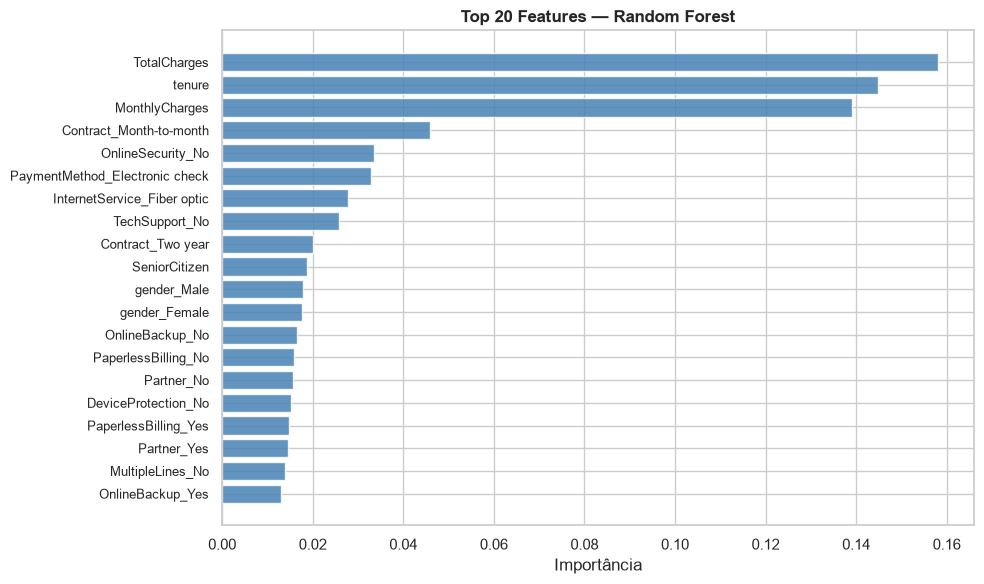

In [10]:
rf_model = trained_models['random_forest']
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]
top_features = feature_names[top_idx]
top_importances = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n), top_importances[::-1], color='steelblue', alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f.replace('cat__', '').replace('num__', '') for f in top_features[::-1]], fontsize=9)
ax.set_xlabel('Importância')
ax.set_title(f'Top {top_n} Features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/baselines_feature_importance.png', bbox_inches='tight')
plt.show()

## 9. Resumo

In [11]:
print('=== RESUMO DOS BASELINES ===')
print()
for name in BASELINES:
    te = results_test[name]
    cv = results_cv[name]
    print(f'{name:25s} | AUC-ROC: {te["roc_auc"]:.4f} | PR-AUC: {te["pr_auc"]:.4f} | F1: {te["f1"]:.4f} | Custo: R${te["business_cost"]:,.0f}')

print()
best_auc = max(BASELINES, key=lambda n: results_test[n]['roc_auc'])
best_cost = min(BASELINES, key=lambda n: results_test[n]['business_cost'])
print(f'Melhor AUC-ROC:      {best_auc} ({results_test[best_auc]["roc_auc"]:.4f})')
print(f'Menor custo negócio: {best_cost} (R${results_test[best_cost]["business_cost"]:,.0f})')
print()
print('→ O MLP PyTorch deve superar estes valores.')
print(f'→ Target MLP: AUC-ROC > {results_test[best_auc]["roc_auc"]:.4f}')

=== RESUMO DOS BASELINES ===

dummy                     | AUC-ROC: 0.5000 | PR-AUC: 0.2652 | F1: 0.0000 | Custo: R$93,500
logistic_regression       | AUC-ROC: 0.8528 | PR-AUC: 0.6575 | F1: 0.5710 | Custo: R$18,550
random_forest             | AUC-ROC: 0.8211 | PR-AUC: 0.6273 | F1: 0.5629 | Custo: R$20,850
gradient_boosting         | AUC-ROC: 0.8510 | PR-AUC: 0.6775 | F1: 0.5876 | Custo: R$19,200
xgboost                   | AUC-ROC: 0.8294 | PR-AUC: 0.6510 | F1: 0.5891 | Custo: R$22,550

Melhor AUC-ROC:      logistic_regression (0.8528)
Menor custo negócio: logistic_regression (R$18,550)

→ O MLP PyTorch deve superar estes valores.
→ Target MLP: AUC-ROC > 0.8528
